# Zomato EDA Project

### Objective:
- Analyse the Zomato restaurant dataset to understand customer preferences and business trends  
- Identify factors influencing restaurant ratings, votes, and popularity  
- Explore cost distribution and its relationship with ratings  

### Dataset Description
- Contains ~50,000 restaurant records from Zomato platform  
- Columns include: name, location, cuisines, cost, rating, votes, restaurant type, etc.  
- Data covers multiple cities and restaurant categories  

### Goals
- Perform step‑wise Exploratory Data Analysis (EDA)  
- Detect missing values and clean dataset for consistency  
- Visualize top cuisines, restaurant types, and city‑wise distribution  
- Generate insights useful for business decision making and customer engagement

#### Data Loading & importing libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("zomato.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [4]:
df.shape

(51717, 17)

### Data Cleaning :-
#### Purpose
- Ensure dataset has only useful columns  
- Convert rating and cost columns to numeric format  
- Handle missing values for consistency  

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

### Remove columns :- url,address,phone,review_list,menu_item



In [6]:
df.drop(columns=['url','address','phone','reviews_list','menu_item'], inplace =True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         51717 non-null  object
 1   online_order                 51717 non-null  object
 2   book_table                   51717 non-null  object
 3   rate                         43942 non-null  object
 4   votes                        51717 non-null  int64 
 5   location                     51696 non-null  object
 6   rest_type                    51490 non-null  object
 7   dish_liked                   23639 non-null  object
 8   cuisines                     51672 non-null  object
 9   approx_cost(for two people)  51371 non-null  object
 10  listed_in(type)              51717 non-null  object
 11  listed_in(city)              51717 non-null  object
dtypes: int64(1), object(11)
memory usage: 4.7+ MB


In [8]:
df['rate']

0         4.1/5
1         4.1/5
2         3.8/5
3         3.7/5
4         3.8/5
          ...  
51712    3.6 /5
51713       NaN
51714       NaN
51715    4.3 /5
51716    3.4 /5
Name: rate, Length: 51717, dtype: object

In [9]:
# remove '/5' from rate and covert it to float
df['rate'] = df['rate'].str.replace('/5','').str.strip()

In [10]:
df['rate'] = pd.to_numeric(df['rate'],errors='coerce')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51717 non-null  object 
 1   online_order                 51717 non-null  object 
 2   book_table                   51717 non-null  object 
 3   rate                         41665 non-null  float64
 4   votes                        51717 non-null  int64  
 5   location                     51696 non-null  object 
 6   rest_type                    51490 non-null  object 
 7   dish_liked                   23639 non-null  object 
 8   cuisines                     51672 non-null  object 
 9   approx_cost(for two people)  51371 non-null  object 
 10  listed_in(type)              51717 non-null  object 
 11  listed_in(city)              51717 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 4.7+ MB


In [12]:
# clean commas and convert approx_cost(for two people)' to float

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',','')

In [13]:
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51717 non-null  object 
 1   online_order                 51717 non-null  object 
 2   book_table                   51717 non-null  object 
 3   rate                         41665 non-null  float64
 4   votes                        51717 non-null  int64  
 5   location                     51696 non-null  object 
 6   rest_type                    51490 non-null  object 
 7   dish_liked                   23639 non-null  object 
 8   cuisines                     51672 non-null  object 
 9   approx_cost(for two people)  51371 non-null  float64
 10  listed_in(type)              51717 non-null  object 
 11  listed_in(city)              51717 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 4.7+ MB


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51717 non-null  object 
 1   online_order                 51717 non-null  object 
 2   book_table                   51717 non-null  object 
 3   rate                         41665 non-null  float64
 4   votes                        51717 non-null  int64  
 5   location                     51696 non-null  object 
 6   rest_type                    51490 non-null  object 
 7   dish_liked                   23639 non-null  object 
 8   cuisines                     51672 non-null  object 
 9   approx_cost(for two people)  51371 non-null  float64
 10  listed_in(type)              51717 non-null  object 
 11  listed_in(city)              51717 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 4.7+ MB


## Handle Missing values and duplicates

In [16]:
df.isnull().sum()

name                               0
online_order                       0
book_table                         0
rate                           10052
votes                              0
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [17]:
df.shape

(51717, 12)

In [18]:
# here we use median to replace missing values, because missing value ia approx 20% of dataset
median_rate = df['rate'].median() 

In [19]:
df['rate'] = df['rate'].fillna(median_rate)

In [20]:
# disk_liked is categorical data , so we use mode to replace NaN
dish_mode = df['dish_liked'].mode()[0]

In [21]:
 df['dish_liked'] = df['dish_liked'].fillna(dish_mode)

In [22]:
df['dish_liked'].isnull().sum()

0

In [23]:
df.isnull().sum()

name                             0
online_order                     0
book_table                       0
rate                             0
votes                            0
location                        21
rest_type                      227
dish_liked                       0
cuisines                        45
approx_cost(for two people)    346
listed_in(type)                  0
listed_in(city)                  0
dtype: int64

In [24]:
# now we drop approx_cost,location,rest_type,because they are less tha 0.5%
df = df.dropna(subset = ['location','rest_type','approx_cost(for two people)','cuisines'])

In [25]:
df.shape

(51148, 12)

In [26]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
listed_in(city)                0
dtype: int64

### Exploratory Data analysis

### Rating Distribution 

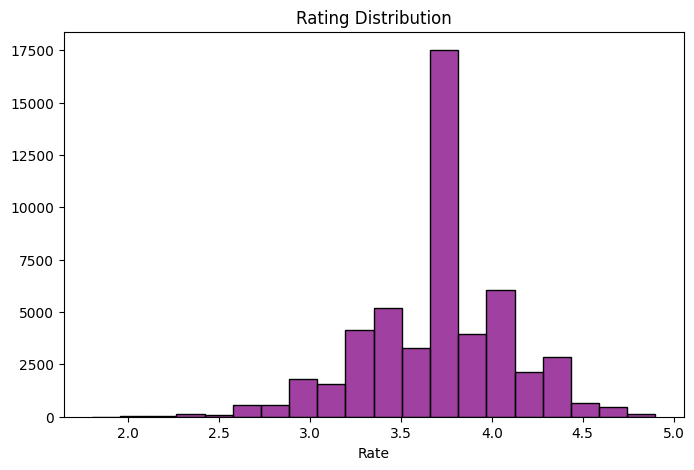

In [85]:
# Rating distribution
plt.figure(figsize=(8,5))
sns.histplot(df['rate'],bins = 20, color='purple')
plt.title('Rating Distribution')
plt.xlabel("Rate")
plt.ylabel("")
plt.show()

### Observation:-
* Highest rating is between 3.5 to 4 

### Votes Distribution

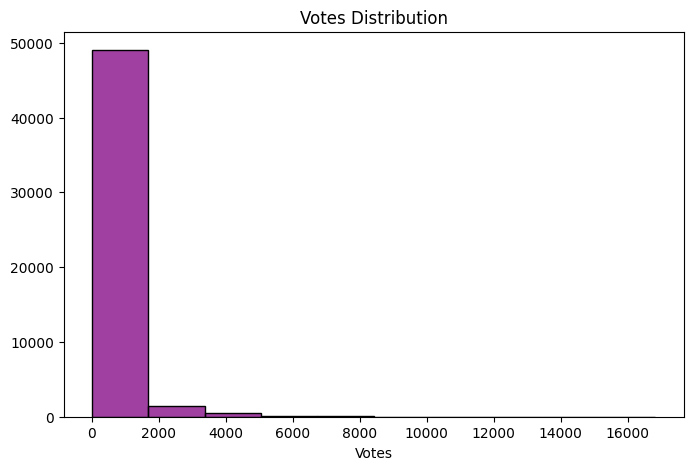

In [93]:
plt.figure(figsize=(8,5))
sns.histplot(df['votes'], bins=10, color='purple')
plt.title("Votes Distribution")
plt.xlabel("Votes")
plt.ylabel("")
plt.xticks(np.arange(0,18000,2000))
plt.show()

### Observation:-
* This shows the highest number of people not giving votes; they are not using the rating/voting system

### Cost Distribution

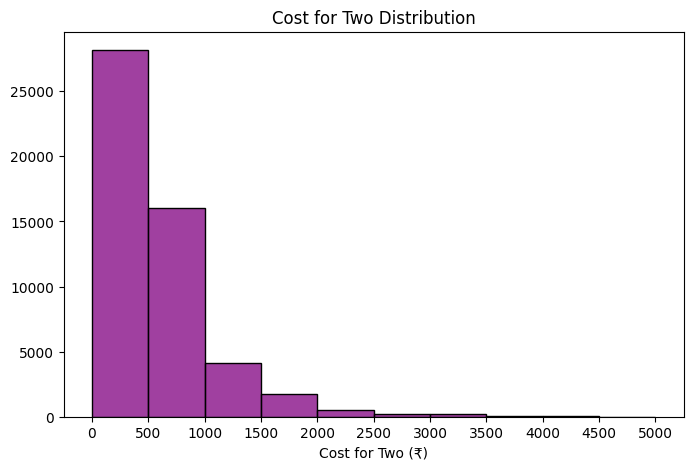

In [88]:
# Cost for Two Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['approx_cost(for two people)'], bins=[0,500,1000,1500,2000,2500,3000,3500,4000,4500,5000],color='purple')
plt.title("Cost for Two Distribution")
plt.xlabel("Cost for Two (₹)")
plt.ylabel("")
plt.xticks(np.arange(0, 5001, 500))
plt.show()

### Observation:
* Most restaurants fall in low to medium cost range(below ₹1000),showing that majority are affordable.
* Very few restaurant are expensive (above ₹2000)

### Restaurant Types

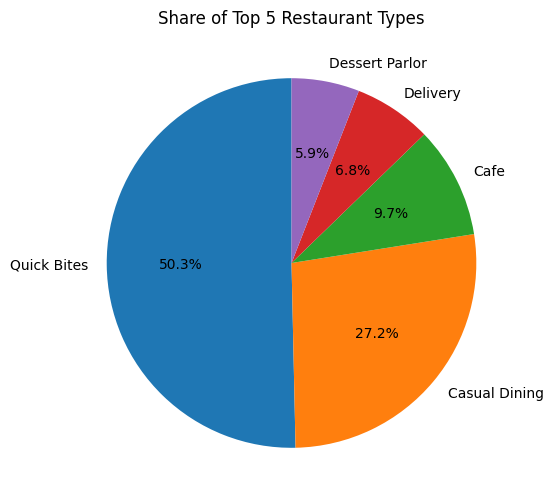

In [68]:
# Top 5 restaurant types for a pie chart
rest_counts = df['rest_type'].value_counts().head(5)

plt.figure(figsize=(6,6))
rest_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Share of Top 5 Restaurant Types")
plt.ylabel("")
plt.show()

### Observation:
* Quick Bites and Casual Dining are the most preferred restaurant types, dominating the market among others

### Popular Cuisines

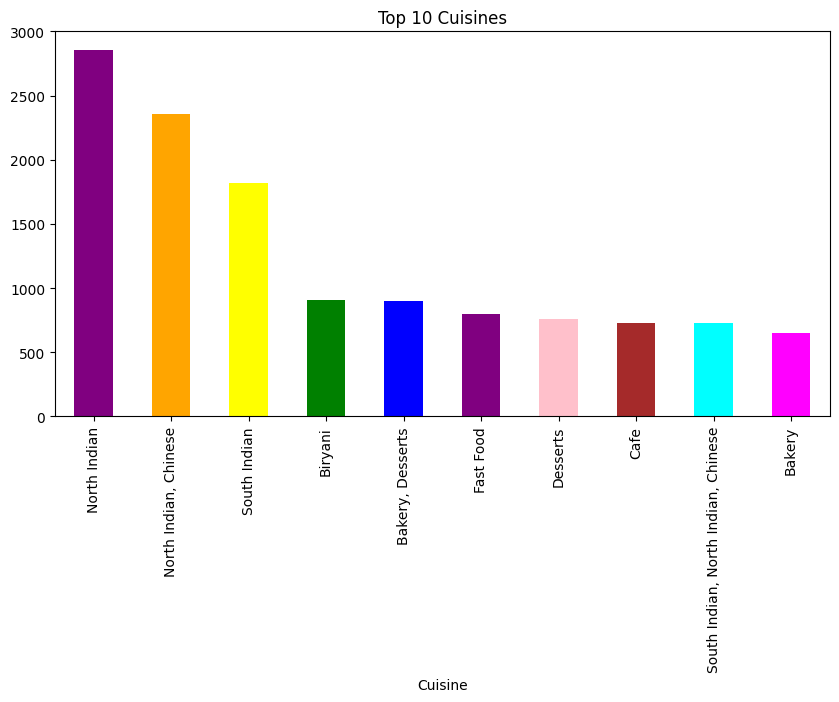

In [101]:
plt.figure(figsize=(10,5))
colors = ['purple','orange','yellow','green','blue','purple','pink','brown','cyan','magenta']
df['cuisines'].value_counts().head(10).plot(kind='bar', color=colors)
plt.title("Top 10 Cuisines")
plt.xlabel("Cuisine")
plt.show()

### Observation:
* North Indian cuisine are dominate, followed by combinations like North indian + chinese and south indian.


### Location Wise 

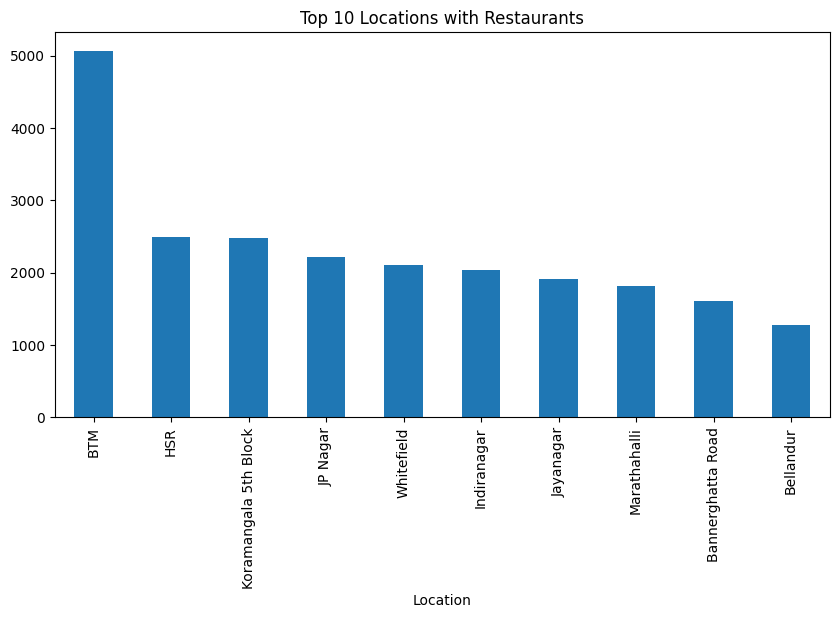

In [67]:
plt.figure(figsize=(10,5))
df['location'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Locations with Restaurants")
plt.xlabel("Location")
plt.show()

### Observation
*BTM has the highest number of restaurants, followed by HSR and Koramangala 5th Block, while Bellandur has the lowest among the top 10

### Final insights:
* Most resturant are affordable, cost for 2 people is usually belloe (₹2000)
* Quick Bites and Casual Dinnig dominate, these are the most common restaurant type
* North Indian cuisine leads overall
* Customer engagement is low ,most customer are not using rating/voting system